# Lecture 17 - Part 1: FLDA for Multiples Classes

---

Last class, we started the discussion of **linear discriminant functions for classification**. A linear discriminant function for classification as the following mapper function form:

\begin{align*}
y(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + w_0
\end{align*}

where $\mathbf{w}$ are the parameters of the model ($D\times 1$ vector), $w_0$ the intercept/bias of the model (scalar value), and $y(\mathbf{x})$ is the output value.

This mapper function resembles a mapper function for a **regression** task. In fact, without any other transformation, the output value $y(\mathbf{x})$ is continuous-valued.

Take the example of **Fisher's Linear Discriminant Analysis (FLDA)** covered last class, where a linear discriminant function is found such that:

1. the between-class scatter, $S_B$, is maximized (separated)
2. the within-class scatter, $S_W$, is minimized (compact)

That is,

\begin{align*}
\arg_{\mathbf{w}} \max J(\mathbf{w}) = \arg_{\mathbf{w}} \max \frac{\mathbf{w}^TS_B\mathbf{w}}{\mathbf{w}^TS_W\mathbf{w}}
\end{align*}

For a 2-class problem, we use the following **decision rule**:

\begin{align*}
\text{Decide }\begin{cases}\mathbf{x}\in C_1 & \text{if }\;\;y(\mathbf{x})>0\\\mathbf{x}\in C_2 & \text{if }\;\;y(\mathbf{x})<0\end{cases}
\end{align*}

For a multi-class problem (more than 2), a one-vs-all approach can lead to ambiguous regions. Thus, we can first define $k$ discriminant functions, $y_k(\mathbf{x})$, then the decision rule is

\begin{align*}
\text{Decide }\;\; \mathbf{x}\in C_i \;\; \text{ if }\;\; y_i(\mathbf{x})>y_j(\mathbf{x}),\;\; \forall i\neq j
\end{align*}

## LDA Discriminant Function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

X = np.load('data.npy')
t = np.load('labels.npy')
t[t==0]=-1

plt.scatter(X[:,0], X[:,1], c=t);

X.shape, t.shape

In [ ]:
# Class means
m1 = np.mean(X[t==0,:],axis=0).reshape(-1,1)
m2 = np.mean(X[t==1,:],axis=0).reshape(-1,1)

# Between-class scatter matrix
SB = (m2-m1)@(m2-m1).T

SB

In [ ]:
# within-class scatter
SW = (X[t==0,:]-m1.T).T@(X[t==0,:]-m1.T) + (X[t==1,:]-m2.T).T@(X[t==1,:]-m2.T)

SW

In [ ]:
# Eigendecomposition of SW^-1@SB

# eigendecompoition for hermitian matrices
L, E = np.linalg.eigh(np.linalg.inv(SW)@SB)
L, E

In [ ]:
# the w vector is the eigenvector with largest eigenvalue

w = E[:,1]
w

In [ ]:
# Verify that it is a length=1 vector

np.linalg.norm(w)

In [ ]:
# Intercept/bias term

w0 = (m1+m2).T@w/2
w0

In [ ]:
def discriminant(data, labels, w, w0):
    # perpendicular vector to w (swap entries and negate one of them)
    w_perp = np.array([w[1], -w[0]])
    
    # points on the real line for plotting
    x = np.linspace(-15,10,data.shape[0])
    
    # plotting direction of projection
    proj_line = x * w.reshape(-1,1)
    
    # discriminant function (orthogonal line of direction of projection)
    discriminant_fct = w0 * w.reshape(-1,1) + x * w_perp.reshape(-1,1)
    
    return proj_line, discriminant_fct

proj_line, discriminant_fct = discriminant(X, t, w, w0);

plt.scatter(X[:,0],X[:,1],c=t)
plt.plot(proj_line[0], proj_line[1], 'red', linewidth=3, 
         label='Projection Line')
plt.plot(discriminant_fct[0,:], discriminant_fct[1,:],'blue',linewidth=3, 
         label='Discriminant Function')
plt.title('LDA'); plt.axis('equal'); plt.legend(loc='best',fontsize=10);

## Least Squares Discriminant Function

In [ ]:
X_mat = np.hstack((np.ones((X.shape[0],1)), X))

X_mat.shape

In [ ]:
w_ls = np.linalg.inv(X_mat.T@X_mat)@X_mat.T@t

w_ls

In [ ]:
x = np.linspace(-10,10,X.shape[0])

y_ls = -w_ls[0]/w_ls[2] - (w_ls[1]/w_ls[2])*x

y_ls.shape

In [ ]:
plt.scatter(X[:,0],X[:,1],c=t)
plt.plot(discriminant_fct[0,:], discriminant_fct[1,:],'blue',linewidth=3,label='LDA')
plt.plot(x, y_ls,'black',linewidth=3, label='Least Squares')
plt.title('Discriminant Functions');plt.axis('equal'); plt.legend(loc='best',fontsize=10);

---

# Multiple Classes

Considering the extension of linear discriminants to $K > 2$ classes. We might be tempted be to build a $K$-class discriminant by combining a number of two-class discriminant functions. However, this leads to some serious difficulties.

* Consider the use of $K−1$ classifiers each of which solves a two-class problem of separating points in a particular class $C_k$ from points not in that class. This is known as a **one-versus-all** classifier.

* An alternative is to introduce $K(K − 1)/2$ binary discriminant functions, one for every possible pair of classes. This is known as a **one-versus-one** classifier. Each point is then classified according to a majority vote amongst the discriminant functions. However, this too runs into the problem of ambiguous regions.

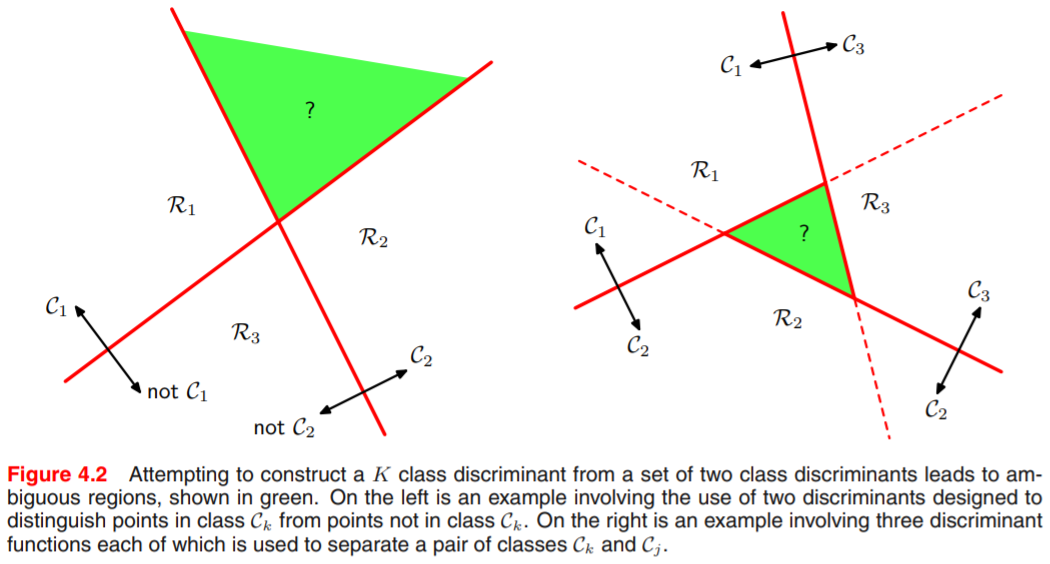

In [1]:
from IPython.display import Image
Image('figures/Figure4.2.png',width=700)
# Source: Bishop textbook

We can avoid these difficulties by considering a **single $K$-class discriminant** comprising $K$ linear functions of the form

\begin{align*}
y_k(\mathbf{x}) = \mathbf{w}_k^T\mathbf{x} + b_k
\end{align*}

and then assigning a point $\mathbf{x}$ to class $C_k$ if $y_k(\mathbf{x}) > y_j(\mathbf{x})$ for all $j \neq k$. The decision
boundary between class $C_k$ and class $C_j$ is therefore given by $y_k(\mathbf{x}) = y_j(\mathbf{x})$ and hence corresponds to a $(D − 1)$-dimensional hyperplane defined by

\begin{align*}
(\mathbf{w}_k - \mathbf{w}_j)^T\mathbf{x} + (b_k - bj) = 0
\end{align*}

This has the same form as the decision boundary for the two-class case.

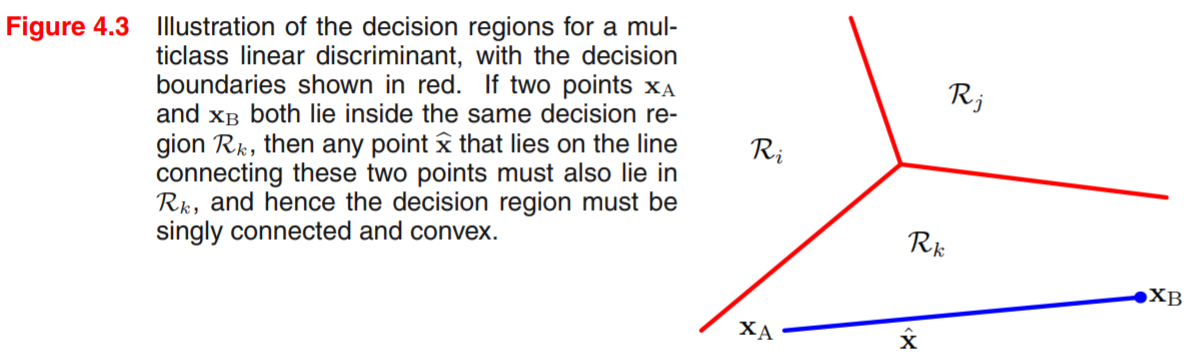

In [2]:
Image('figures/Figure4.3.png',width=800)
# Source: Bishop textbook

The decision regions of such a discriminant are always **singly connected** and **convex**. To see this, consider two points $x_A$ and $x_B$ both of which lie inside decision region $R_k$. Any point $\hat{\mathbf{x}}$ that lies on the line connecting
$x_A$ and $x_B$ can be expressed in the form

\begin{align*}
\hat{\mathbf{x}} = \alpha x_A + (1-\alpha)x_B
\end{align*}

where $0\leq\alpha\leq 1$. From the linearity of the discriminant functions, it follows that

\begin{align*}
y_k(\hat{\mathbf{x}}) = \alpha y_k(x_A) + (1-\alpha)y_k(x_B)
\end{align*}

Because both $x_A$ and $x_B$ lie inside $R_k$, it follows that $y_k(x_A) > y_j(x_A)$, and $y_k(x_B) > y_j(x_B)$, for all $j \neq k$, and hence $y_k(\hat{\mathbf{x}}) > y_j(\hat{\mathbf{x}})$, and so $\hat{\mathbf{x}}$ also lies inside $R_k$. Thus $R_k$ is singly connected and convex.

---

# Fisher's LDA for Multiples Classes

We now consider the generalization of the Fisher discriminant to $K > 2$ classes, and we shall assume that the dimensionality $D$ of the input space is greater than the number $K$ of classes. Next, we introduce $M > 1$ linear "features" $\mathbf{y}_k = \mathbf{w}_k^T\mathbf{x}$, where $k = 1,\dots,M$ and $M\leq D$.

These feature values can conveniently be grouped together to form a vector $\mathbf{y}$. Similarly, the weight vectors $\{\mathbf{w}_k\}$ can be considered to be the columns of a matrix $\mathbf{W}$, so that

\begin{align*}
\mathbf{y} = \mathbf{W}^T\mathbf{x}
\end{align*}

Note that again we are not including any bias parameters in the definition of $\mathbf{y}$. The generalization of the within-class covariance matrix to the case of $K$ classes is as follows:

\begin{align*}
S_W = \sum_{k=1}^K S_k
\end{align*}

where 

\begin{align*}
S_k &= \frac{1}{N_k}\sum_{n\in C_k} (x_n-\mathbf{\overrightarrow{m}}_k)^T(x_n-\mathbf{\overrightarrow{m}}_k)^T\\
\mathbf{\overrightarrow{m}}_k &= \frac{1}{N_k}\sum_{n\in C_k} x_n
\end{align*}

and $N_k$ is the number of patterns in class $C_k$. In order to find a generalization of the between-class covariance matrix, let's consider first the total covariance matrix:

\begin{align*}
S_T = \frac{1}{N}\sum_{n=1}^N (x_n - \mathbf{\overrightarrow{m}})(x_n - \mathbf{\overrightarrow{m}})^T
\end{align*}

where $\mathbf{\overrightarrow{m}}$ is the mean of the total data set 

\begin{align*}
\mathbf{m} = \frac{1}{N}\sum_{n=1}^N x_n = \frac{1}{N} \sum_{k=1}^K N_k\mathbf{\overrightarrow{m}}_k
\end{align*}

and $N = \sum_{k=1}^K N_k$ is the total number of data points.

The total covariance matrix can be decomposed into the sum of the **within-class covariance scatter matrix** plus an additional matrix $S_B$, which we identify as a measure of the **between-class covariance**:

\begin{align*}
S_T = S_W + S_B
\end{align*}

where 

\begin{align*}
S_B = \sum_{k=1}^K N_k(\mathbf{\overrightarrow{m}}_k - \mathbf{\overrightarrow{m}})(\mathbf{\overrightarrow{m}}_k-\mathbf{\overrightarrow{m}})^T
\end{align*}

These covariance matrices have been defined in the original x-input space. We can now define similar matrices in the projected $M$-dimensional y-space:

\begin{align*}
s_W = \sum_{k=1}^K\sum_{n\in C_k} (\mathbf{y}_n - \mathbf{\mu}_k)(\mathbf{y}_n - \mathbf{\mu}_k)^T
\end{align*}

and

\begin{align*}
s_B = \sum_{k=1}^K N_k(\mathbf{\mu}_k -\mathbf{\mu})(\mathbf{\mu}_k -\mathbf{\mu})^T
\end{align*}

where 

\begin{align*}
\mathbf{\mu}_k &= \frac{1}{N_k}\sum_{n\in C_k} y_n\\
\mathbf{\mu} &= \frac{1}{N} \sum_{k=1}^K N_k \mathbf{\mu}_k
\end{align*}

Once again, we wish to construct a scalar that is large when the between-class covariance is large and when the within-class covariance is small.

\begin{align*}
J(\mathbf{W}) = \frac{s_B}{s_W}
\end{align*}

This criterion can then be rewritten as an explicit function of the projection matrix $\mathbf{W}$ in the form

\begin{align*}
J(\mathbf{w}) = \frac{\mathbf{W}S_B\mathbf{W}^T}{\mathbf{W}S_W\mathbf{W}^T}
\end{align*}

Maximization of such criteria is straightforward, though somewhat involved. The weight values are determined by those eigenvectors of $S_W^{-1}S_B$ that correspond to the $M$ largest eigenvalues.

There is one important result that is common to all such criteria, which is worth emphasizing. We first note that SB is composed of the sum of $K$ matrices, each of which is an outer product of two vectors and therefore of rank 1. In addition, only $(K - 1)$ of these matrices are independent. Thus, $S_B$ has rank at most equal to $(K - 1)$ and so there are at most $(K - 1)$ nonzero eigenvalues. 

This shows that the projection onto the $(K − 1)$-dimensional subspace spanned by the eigenvectors of $S_B$ does not alter the value of $J(\mathbf{w})$, and so we are therefore unable to find more than $(K - 1)$ linear "features".

---

## Limitations of FLDA

1. LDA produces at most $K-1$ feature projections, where $K$ is the number of classes.

2. If the classification error estimates establish that more features are needed, some other method must be employed to provide those additional features.

3. LDA is a parametric method (it assumes unimodal Gaussian likelihoods).

4. If the distributions are significantly non-Gaussian, the LDA projections may not preserve complex structure in the data needed for classification.

5. LDA will also fail if discriminatory information is not in the mean but in the variance of the data.

A popular variant of LDA are the **Multi-Layer Perceptrons** (or MLPs).

---